# 04 - Root Cause Analysis (RCA)
**Project:** E-Commerce Ad Campaign Analytics  
**Author:** Sahil  
**Description:** When a KPI drops, this notebook walks through a structured 5-step RCA framework to diagnose the root cause and surface a recommendation. This mirrors the exact analytical workflow expected at Criteo.

---
### The 5-Step RCA Framework
| Step | Question |
|---|---|
| 1. Detect | Which KPI dropped? By how much? When? |
| 2. Decompose | Is it a CTR problem, CVR problem, CPC problem, or AOV problem? |
| 3. Drill Down | Which channel / category / campaign is causing it? |
| 4. Validate | Is the drop statistically meaningful or just noise? |
| 5. Recommend | What should the team do about it? |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Path to processed data
BASE_DIR = Path(r"C:\Users\F0001215\Jupyter Notebook\ecommerce-ad-analytics")
PROC_DIR = BASE_DIR / "data" / "processed"

# Display settings
pd.set_option("display.float_format", "{:.3f}".format)

# Read dataset
ad = pd.read_csv(
    PROC_DIR / "ad_campaigns.csv",
    parse_dates=["date"]
)

# Weekly column
ad["week"] = ad["date"].dt.to_period("W").dt.start_time

print(f" Loaded {len(ad):,} rows")

# Preview
display(ad.head())

# Check information
print("\nDataset Shape:", ad.shape)
print("\nColumns:")
print(ad.columns.tolist())

 Loaded 14,036 rows


,date,campaign_id,campaign_name,channel,product_category_eng,impressions,clicks,ad_spend,attributed_orders,attributed_revenue,week
0,2017-01-01,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,13211,949,2923.170,36,6368.390,2016-12-26
1,2017-01-02,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,49741,3012,7820.520,97,17110.900,2017-01-02
2,2017-01-03,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,83727,6111,19120.010,238,49462.050,2017-01-02
3,2017-01-04,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,91900,7057,23230.360,289,51407.680,2017-01-02
4,2017-01-05,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,61430,3882,10516.300,131,25441.790,2017-01-02



Dataset Shape: (14036, 11)

Columns:
['date', 'campaign_id', 'campaign_name', 'channel', 'product_category_eng', 'impressions', 'clicks', 'ad_spend', 'attributed_orders', 'attributed_revenue', 'week']


---
## STEP 1 - Detect the Problem
Scan all channels for weeks where ROAS dropped more than 10% week-over-week.

In [2]:
import numpy as np

weekly_channel = (
    ad.groupby(['week', 'channel'])
      .agg(
          impressions=('impressions', 'sum'),
          clicks=('clicks', 'sum'),
          attributed_orders=('attributed_orders', 'sum'),
          ad_spend=('ad_spend', 'sum'),
          attributed_revenue=('attributed_revenue', 'sum')
      )
      .assign(
          ctr=lambda d: np.where(d['impressions'] > 0,
                                 d['clicks'] / d['impressions'],
                                 np.nan),

          cvr=lambda d: np.where(d['clicks'] > 0,
                                 d['attributed_orders'] / d['clicks'],
                                 np.nan),

          cpc=lambda d: np.where(d['clicks'] > 0,
                                 d['ad_spend'] / d['clicks'],
                                 np.nan),

          aov=lambda d: np.where(d['attributed_orders'] > 0,
                                 d['attributed_revenue'] / d['attributed_orders'],
                                 np.nan),

          roas=lambda d: np.where(d['ad_spend'] > 0,
                                  d['attributed_revenue'] / d['ad_spend'],
                                  np.nan)
      )
      .reset_index()
)

# Sort by channel and week
weekly_channel = weekly_channel.sort_values(['channel', 'week'])

# Previous week's ROAS
weekly_channel['roas_prev'] = (
    weekly_channel.groupby('channel')['roas'].shift(1)
)

# WoW % change
weekly_channel['roas_wow_chg'] = (
    (weekly_channel['roas'] - weekly_channel['roas_prev'])
    / weekly_channel['roas_prev']
)

# Replace infinities and round
weekly_channel['roas_wow_chg'] = (
    weekly_channel['roas_wow_chg']
    .replace([np.inf, -np.inf], np.nan)
    .round(3)
)

# Significant drops (>10%)
drops = (
    weekly_channel[
        weekly_channel['roas_wow_chg'] < -0.10
    ]
    .copy()
    .sort_values('roas_wow_chg')
)

# Alert levels
def alert(change):
    if pd.isna(change):
        return "N/A"
    elif change < -0.20:
        return "Severe (>20%)"
    elif change < -0.10:
        return "Moderate (10–20%)"
    return "Stable"

drops['alert'] = drops['roas_wow_chg'].apply(alert)

print(f"Weeks with ROAS drop >10% WoW: {len(drops)}\n")

display(
    drops[
        ['week', 'channel', 'roas', 'roas_prev', 'roas_wow_chg', 'alert']
    ]
)

Weeks with ROAS drop >10% WoW: 13



,week,channel,roas,roas_prev,roas_wow_chg,alert
6,2017-01-02,Meta Ads,2.989,3.683,-0.189,Moderate (10–20%)
8,2017-01-09,Display,4.595,5.463,-0.159,Moderate (10–20%)
236,2018-02-12,Display,4.717,5.519,-0.145,Moderate (10–20%)
282,2018-04-30,Meta Ads,2.831,3.288,-0.139,Moderate (10–20%)
288,2018-05-14,Display,4.673,5.377,-0.131,Moderate (10–20%)
132,2017-08-14,Display,4.861,5.577,-0.128,Moderate (10–20%)
348,2018-08-27,Display,4.557,5.217,-0.127,Moderate (10–20%)
86,2017-05-22,Meta Ads,2.875,3.278,-0.123,Moderate (10–20%)
85,2017-05-22,Google Search,2.780,3.133,-0.113,Moderate (10–20%)
344,2018-08-20,Display,5.217,5.877,-0.112,Moderate (10–20%)


In [3]:
# Pick the most severe drop for deep-dive
worst_row   = drops.iloc[0]
RCA_CHANNEL = worst_row['channel']
RCA_WEEK    = worst_row['week']

print(f'   Deep-diving into:')
print(f'   Channel : {RCA_CHANNEL}')
print(f'   Week    : {RCA_WEEK.date()}')
print(f'   ROAS    : {worst_row["roas"]:.3f}  (prev: {worst_row["roas_prev"]:.3f})')
print(f'   WoW chg : {worst_row["roas_wow_chg"]*100:.1f}%')

   Deep-diving into:
   Channel : Meta Ads
   Week    : 2017-01-02
   ROAS    : 2.989  (prev: 3.683)
   WoW chg : -18.9%


---
## STEP 2 - Decompose the Drop
ROAS = CTR × CVR × AOV / CPC.  
Which driver changed the most?

In [4]:
ch_data = weekly_channel[weekly_channel['channel'] == RCA_CHANNEL].copy()

# Add WoW change for each driver
for metric in ['ctr','cvr','cpc','aov']:
    ch_data[f'{metric}_prev'] = ch_data[metric].shift(1)
    ch_data[f'{metric}_wow']  = ((ch_data[metric] - ch_data[f'{metric}_prev'])
                                  / ch_data[f'{metric}_prev']).round(3)

# Focus on the problem week
problem_week = ch_data[ch_data['week'] == RCA_WEEK].iloc[0]

drivers = pd.DataFrame({
    'Driver'    : ['CTR', 'CVR', 'CPC', 'AOV'],
    'Current'   : [problem_week['ctr'],  problem_week['cvr'],
                   problem_week['cpc'],  problem_week['aov']],
    'Previous'  : [problem_week['ctr_prev'], problem_week['cvr_prev'],
                   problem_week['cpc_prev'], problem_week['aov_prev']],
    'WoW Change': [problem_week['ctr_wow'],  problem_week['cvr_wow'],
                   problem_week['cpc_wow'],  problem_week['aov_wow']]
})

# Identify biggest driver
# For CPC, an INCREASE is bad (costs more); for others a DECREASE is bad
drivers['Impact'] = drivers.apply(
    lambda r: -r['WoW Change'] if r['Driver'] == 'CPC' else r['WoW Change'], axis=1
)
root_driver = drivers.loc[drivers['Impact'].abs().idxmax(), 'Driver']

display(drivers)
print(f'\n🔎 PRIMARY ROOT CAUSE: {root_driver} shift is the biggest contributor')

,Driver,Current,Previous,WoW Change,Impact
0,CTR,0.041,0.039,0.061,0.061
1,CVR,0.025,0.028,-0.096,-0.096
2,CPC,1.206,1.261,-0.044,0.044
3,AOV,141.801,165.301,-0.142,-0.142



🔎 PRIMARY ROOT CAUSE: AOV shift is the biggest contributor


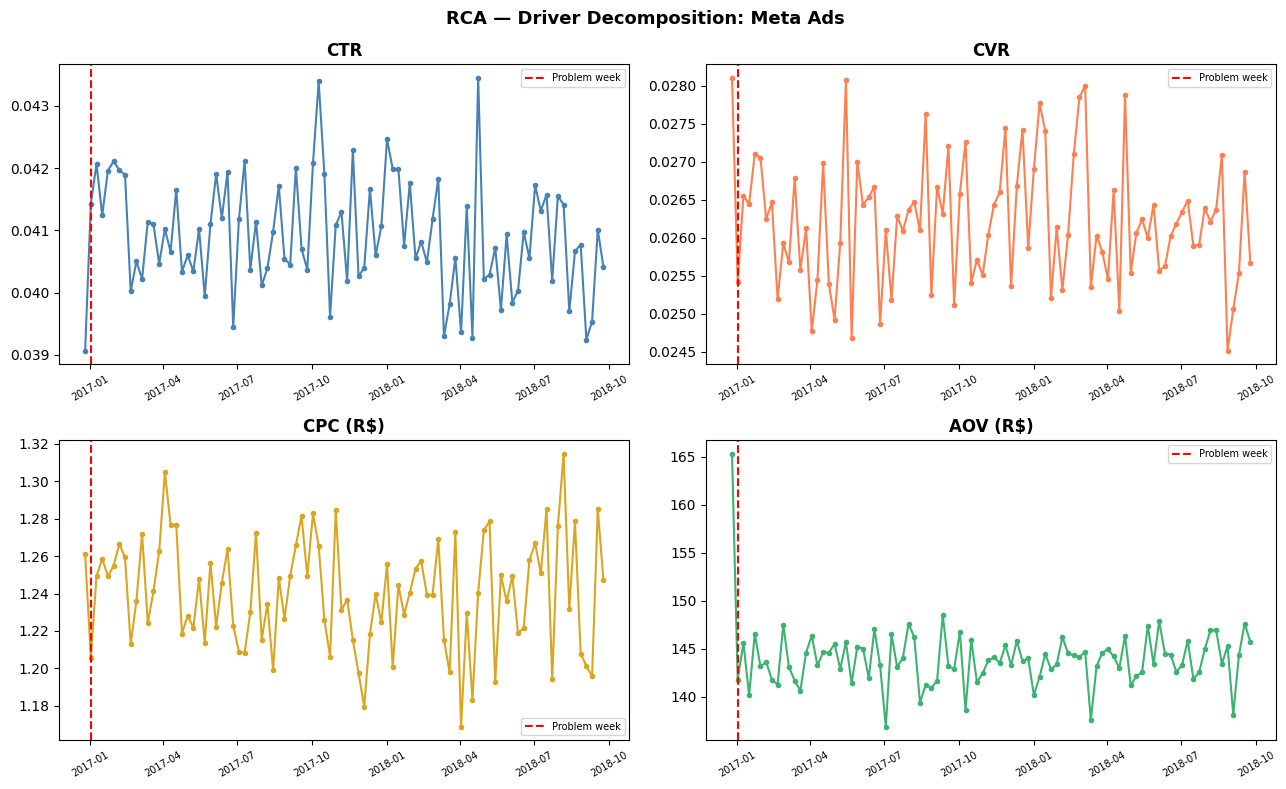

In [5]:
# Visualise driver decomposition
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f'RCA — Driver Decomposition: {RCA_CHANNEL}', fontsize=13, fontweight='bold')

metrics  = [('ctr','CTR','steelblue'), ('cvr','CVR','coral'),
            ('cpc','CPC (R$)','goldenrod'), ('aov','AOV (R$)','mediumseagreen')]

for ax, (col, label, color) in zip(axes.flat, metrics):
    ax.plot(ch_data['week'], ch_data[col], color=color, linewidth=1.5, marker='o', markersize=3)
    ax.axvline(RCA_WEEK, color='red', linestyle='--', linewidth=1.5, label='Problem week')
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(PROC_DIR / 'rca_driver_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 3 — Drill Down
Which product category within the affected channel drove the drop?

In [6]:
PREV_WEEK = RCA_WEEK - pd.Timedelta(weeks=1)

def week_kpis(week):
    subset = ad[(ad['date'] >= week) & (ad['date'] < week + pd.Timedelta(weeks=1))
                & (ad['channel'] == RCA_CHANNEL)]
    return subset.groupby('product_category_eng').agg(
        impressions       = ('impressions',       'sum'),
        clicks            = ('clicks',            'sum'),
        attributed_orders = ('attributed_orders', 'sum'),
        ad_spend          = ('ad_spend',          'sum'),
        attributed_revenue= ('attributed_revenue','sum')
    ).assign(
        ctr  = lambda d: (d['clicks'] / d['impressions'] * 100).round(2),
        cvr  = lambda d: (d['attributed_orders'] / d['clicks'] * 100).round(2),
        roas = lambda d: (d['attributed_revenue'] / d['ad_spend']).round(2)
    )

curr_cats = week_kpis(RCA_WEEK)
prev_cats = week_kpis(PREV_WEEK)

comparison = curr_cats[['roas','ctr','cvr','ad_spend']].join(
    prev_cats[['roas','ctr','cvr']],
    lsuffix='_curr', rsuffix='_prev'
)
comparison['roas_chg'] = ((comparison['roas_curr'] - comparison['roas_prev'])
                           / comparison['roas_prev'] * 100).round(1)

print(f'Category performance in {RCA_CHANNEL} - problem week vs prior week:')
display(comparison.sort_values('roas_chg').head(10))

worst_cat = comparison['roas_chg'].idxmin()
print(f'\n Most affected category: {worst_cat}  (ROAS change: {comparison.loc[worst_cat,"roas_chg"]:.1f}%)')

Category performance in Meta Ads - problem week vs prior week:


,roas_curr,ctr_curr,cvr_curr,ad_spend,roas_prev,ctr_prev,cvr_prev,roas_chg
product_category_eng,,,,,,,,
sports_leisure,5.150,4.990,4.000,40331.690,5.700,4.740,3.750,-9.600
housewares,3.750,2.820,3.000,21874.990,4.150,3.030,3.220,-9.600
telephony,1.530,3.960,2.350,36066.760,1.680,3.380,1.990,-8.900
garden_tools,3.870,4.360,2.880,49112.550,4.220,4.950,3.270,-8.300
furniture_decor,1.740,3.590,1.650,47595.050,1.770,3.200,1.440,-1.700
stationery,2.260,4.690,1.690,48584.340,2.290,4.170,1.460,-1.300



 Most affected category: housewares  (ROAS change: -9.6%)


---
## STEP 4 - Validate
Is the drop a real trend or just weekly noise? Check 4-week rolling average.

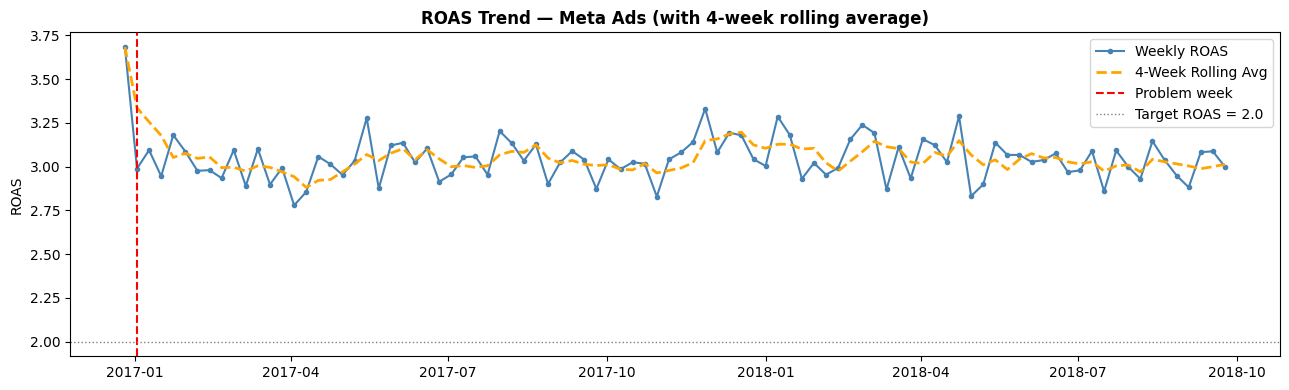

✅ VALIDATED: Problem-week ROAS (2.989) is >10% below 4W avg (3.336) — this is a real drop, not noise.


In [7]:
ch_data_sorted = ch_data.sort_values('week').copy()
ch_data_sorted['roas_4w_avg'] = ch_data_sorted['roas'].rolling(4, min_periods=1).mean()

# Check: is the problem-week ROAS below the 4-week rolling average?
rolling_at_problem = ch_data_sorted[
    ch_data_sorted['week'] == RCA_WEEK
]['roas_4w_avg'].values[0]

problem_roas = problem_week['roas']

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ch_data_sorted['week'], ch_data_sorted['roas'],
        color='steelblue', linewidth=1.5, label='Weekly ROAS', marker='o', markersize=3)
ax.plot(ch_data_sorted['week'], ch_data_sorted['roas_4w_avg'],
        color='orange', linewidth=2, linestyle='--', label='4-Week Rolling Avg')
ax.axvline(RCA_WEEK, color='red', linestyle='--', linewidth=1.5, label='Problem week')
ax.axhline(2.0, color='gray', linestyle=':', linewidth=1, label='Target ROAS = 2.0')
ax.set_title(f'ROAS Trend — {RCA_CHANNEL} (with 4-week rolling average)', fontweight='bold')
ax.set_ylabel('ROAS')
ax.legend()
plt.tight_layout()
plt.savefig(PROC_DIR / 'rca_trend_validation.png', dpi=150, bbox_inches='tight')
plt.show()

if problem_roas < rolling_at_problem * 0.90:
    print(f'✅ VALIDATED: Problem-week ROAS ({problem_roas:.3f}) is >10% below 4W avg ({rolling_at_problem:.3f}) — this is a real drop, not noise.')
else:
    print(f'⚠️  NOISE: Problem-week ROAS ({problem_roas:.3f}) is within normal range of 4W avg ({rolling_at_problem:.3f}) — may be statistical noise.')

---
## STEP 5 - Recommend
Summarise findings and produce a clear, actionable recommendation.

In [8]:
# Budget reallocation: if we shift 15% from worst channel to best ROAS channel
channel_roas = ad.groupby('channel').apply(
    lambda x: x['attributed_revenue'].sum() / x['ad_spend'].sum()
).round(2)

total_spend  = ad['ad_spend'].sum()
worst_spend  = ad[ad['channel'] == RCA_CHANNEL]['ad_spend'].sum()
best_channel = channel_roas.idxmax()
best_roas    = channel_roas.max()
shift_amount = worst_spend * 0.15
est_revenue_gain = shift_amount * best_roas

print('=' * 60)
print('  RCA SUMMARY & RECOMMENDATIONS')
print('=' * 60)
print(f'  Problem channel  : {RCA_CHANNEL}')
print(f'  Problem week     : {RCA_WEEK.date()}')
print(f'  ROAS drop        : {worst_row["roas_wow_chg"]*100:.1f}%')
print(f'  Primary driver   : {root_driver} shift')
print(f'  Most affected cat: {worst_cat}')
print()
print('  RECOMMENDED ACTIONS:')

if root_driver == 'CTR':
    print('  1. Rotate ad creatives for underperforming category — creative fatigue likely')
    print('  2. Review audience targeting — segment may be oversaturated')
    print('  3. A/B test new headline + image combinations in the next 2 weeks')
elif root_driver == 'CVR':
    print('  1. Audit landing page for the affected category — check load speed and CTA clarity')
    print('  2. Review offer competitiveness — competitor may have launched a promotion')
    print('  3. Add social proof (reviews, ratings) to product landing pages')
elif root_driver == 'CPC':
    print('  1. CPC increase indicates rising auction competition — review bid strategy')
    print('  2. Shift to target CPA bidding to cap cost per acquisition')
    print('  3. Explore long-tail keywords / narrower audiences to reduce CPC')
else:  # AOV
    print('  1. AOV drop — check if high-value SKUs in category are out of stock')
    print('  2. Review pricing / discount settings on affected category')
    print('  3. Add cross-sell / upsell modules on product pages')

print()
print(f'  BUDGET REALLOCATION OPPORTUNITY:')
print(f'  Shift 15% of {RCA_CHANNEL} budget (R${shift_amount:,.0f})')
print(f'  → to {best_channel} (ROAS = {best_roas:.2f}x)')
print(f'  → Estimated additional revenue: R${est_revenue_gain:,.0f}')
print('=' * 60)

  RCA SUMMARY & RECOMMENDATIONS
  Problem channel  : Meta Ads
  Problem week     : 2017-01-02
  ROAS drop        : -18.9%
  Primary driver   : AOV shift
  Most affected cat: housewares

  RECOMMENDED ACTIONS:
  1. AOV drop — check if high-value SKUs in category are out of stock
  2. Review pricing / discount settings on affected category
  3. Add cross-sell / upsell modules on product pages

  BUDGET REALLOCATION OPPORTUNITY:
  Shift 15% of Meta Ads budget (R$3,380,768)
  → to Retargeting (ROAS = 11.11x)
  → Estimated additional revenue: R$37,560,337
